# Visualisation d'une image satellite et de sa prédiction

In [30]:
pip install astrovision --quiet

Note: you may need to restart the kernel to use updated packages.


In [5]:
!export PROJ_LIB=$(python -c "from osgeo import __file__ as f; import os; print(os.path.join(os.path.dirname(f), 'data', 'proj'))")


In [6]:
from app.utils.data import get_file_system

fs = get_file_system()

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
from astrovision.data.satellite_image import (
    SatelliteImage,
)

image_path = "projet-slums-detection/data-raw/PLEIADES/CHARENTE-MARITIME/2024/ORT_LITTORAL-ATLANTIQUE-NORD-2024_0375_6571_LA93_8Bits.tif"

si = SatelliteImage.from_raster(
        file_path=f"/vsis3/{image_path}",
        dep=None,
        date=None,
        n_bands=3,
    )

/opt/python/lib/python3.13/site-packages/osgeo/gdal.py:330: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
Warning 1: PROJ: proj_create_from_database: Cannot find proj.db
Warning 1: The definition of projected CRS EPSG:2154 got from GeoTIFF keys is not the same as the one from the EPSG registry, which may cause issues during reprojection operations. Set GTIFF_SRS_SOURCE configuration option to EPSG to use official parameters (overriding the ones from GeoTIFF keys), or to GEOKEYS to use custom values from GeoTIFF keys and drop the EPSG code.


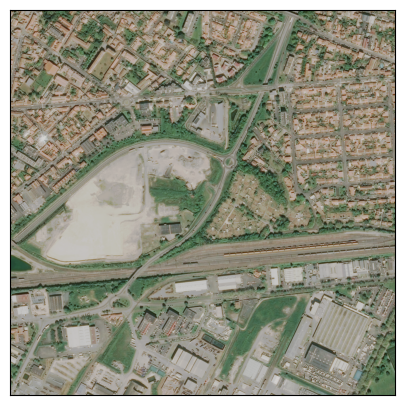

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [8]:
si.plot([0,1,2])

In [10]:
label_path = "projet-slums-detection/cache-predictions/PLEIADES/CHARENTE-MARITIME/2024/Segmentation-multiclass/1/ORT_LITTORAL-ATLANTIQUE-NORD-2024_0375_6571_LA93_8Bits.npy"

In [21]:
import geopandas as gpd

with fs.open(
    "projet-slums-detection/data-prediction/PLEIADES/CHARENTE-MARITIME/2024/Segmentation-multiclass/1/predictions.parquet",
    "rb"
) as f:
    gdf = gpd.read_parquet(f)


In [23]:
from shapely.geometry import box

polygon = box(*si.bounds)

In [24]:
gdf_filtered = gdf[gdf.geometry.intersects(polygon)]


In [27]:
import numpy as np
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_bounds

xmin, ymin, xmax, ymax = si.bounds

resolution = 0.5  # m/pixel

width = int((xmax - xmin) / resolution)
height = int((ymax - ymin) / resolution)

transform = from_bounds(
    xmin, ymin, xmax, ymax,
    width, height
)

# (géométrie, valeur à mettre dans le pixel)
shapes = [
    (geom, label)
    for geom, label in zip(gdf.geometry, gdf["label"])
]

array = rasterize(
    shapes,
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype=np.uint8
)

print(array.shape)
print(array.dtype)


(2000, 2000)
uint8


In [28]:
import numpy as np
from astrovision.data.labeled_satellite_image import (
    SegmentationLabeledSatelliteImage,
)

segmentation_labeled_image = SegmentationLabeledSatelliteImage(
    satellite_image=si, label=array
)

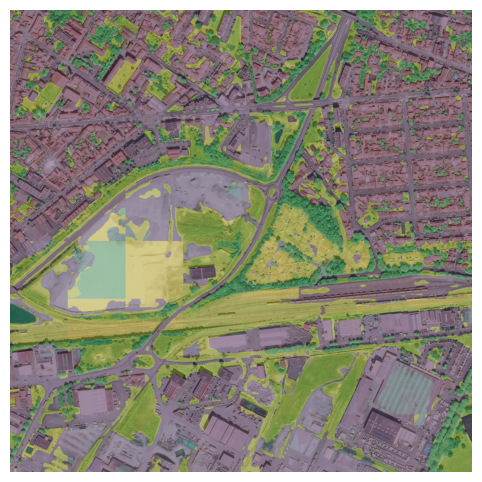

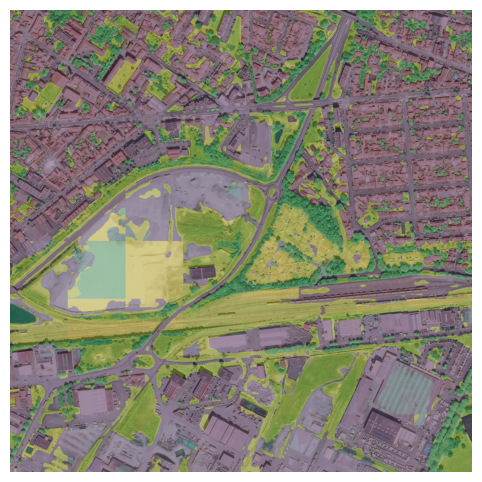

In [29]:
segmentation_labeled_image.plot(bands_indices=[0, 1, 2])